# Classificação de Fezes pela Escala de Bristol
## Transfer Learning com VGG16

Este notebook implementa um modelo de classificação de imagens usando Transfer Learning.

### O que é Transfer Learning?

Transfer Learning usa um modelo pré-treinado (VGG16 treinado no ImageNet com milhões de imagens) e o adapta para nosso problema específico. 

**Vantagens:**
- Funciona bem com poucos dados (~200 imagens)
- Treina muito mais rápido
- Aproveita conhecimento de features visuais universais

### Arquitetura VGG16

```
┌─────────────────────────┐
│   CONVOLUTIONAL BASE    │ ← Extrai features (já treinada)
│  (Feature Extraction)   │   Detecta: bordas, texturas, formas
│   - 13 conv layers      │
│   - 5 pooling layers    │
└─────────────────────────┘
           ↓
┌─────────────────────────┐
│    CLASSIFIER HEAD      │ ← Substituímos para 7 classes
│  - Dense layers         │   (Escala de Bristol)
│  - Nossa: 7 classes     │
└─────────────────────────┘
```

## 1. Instalação e Imports

In [32]:
# Instalar dependências (rode apenas uma vez)
# !pip install tensorflow pandas numpy matplotlib scikit-learn pillow

In [33]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os
from pathlib import Path

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU disponível: []


## 2. Carregar e Explorar os Dados

Total de imagens: 211

Distribuição por tipo Bristol:
bristol_type
1    31
2    12
3    27
4    43
5    35
6    37
7    26
Name: count, dtype: int64


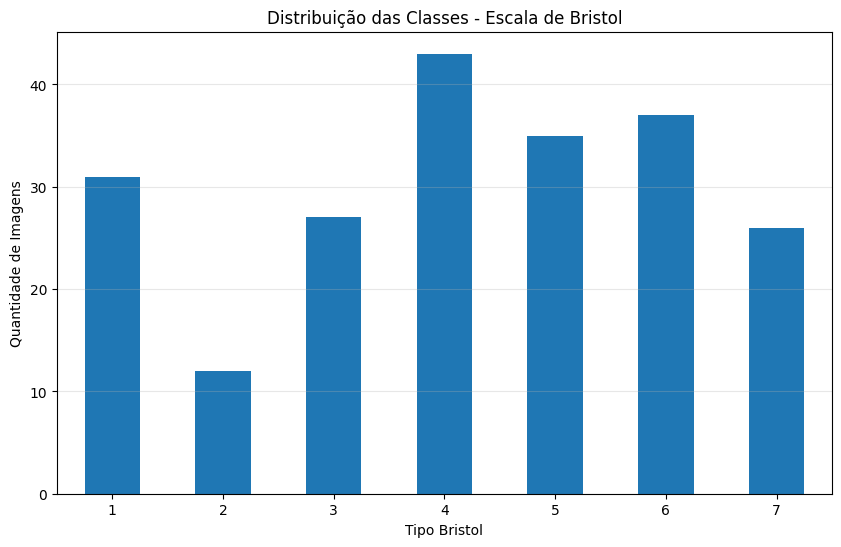

,filename,bristol_type
0,3EYJWti0C3YK.jpg,7
1,8rmwR4PcOGs5.jpg,5
2,guZaWe6VWiGY.jpg,3
3,h5rVydkPXg1T.jpg,6
4,TWvTAHn0L0zL.jpeg,5


In [34]:
# Carregar labels
df = pd.read_csv('labels.csv')

print(f"Total de imagens: {len(df)}")
print(f"\nDistribuição por tipo Bristol:")
print(df['bristol_type'].value_counts().sort_index())

# Visualizar distribuição
plt.figure(figsize=(10, 6))
df['bristol_type'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição das Classes - Escala de Bristol')
plt.xlabel('Tipo Bristol')
plt.ylabel('Quantidade de Imagens')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

df.head()

### Verificar imagens existentes

In [35]:
# Verificar se todas as imagens existem
dataset_path = Path('dataset')
missing_files = []

for filename in df['filename']:
    filepath = dataset_path / filename
    if not filepath.exists():
        missing_files.append(filename)

if missing_files:
    print(f"⚠️  {len(missing_files)} arquivos não encontrados:")
    for f in missing_files[:5]:
        print(f"  - {f}")
    # Remover arquivos faltantes
    df = df[~df['filename'].isin(missing_files)]
else:
    print("✓ Todas as imagens foram encontradas!")

print(f"\nTotal após verificação: {len(df)} imagens")

✓ Todas as imagens foram encontradas!

Total após verificação: 211 imagens


### Visualizar exemplos de cada classe

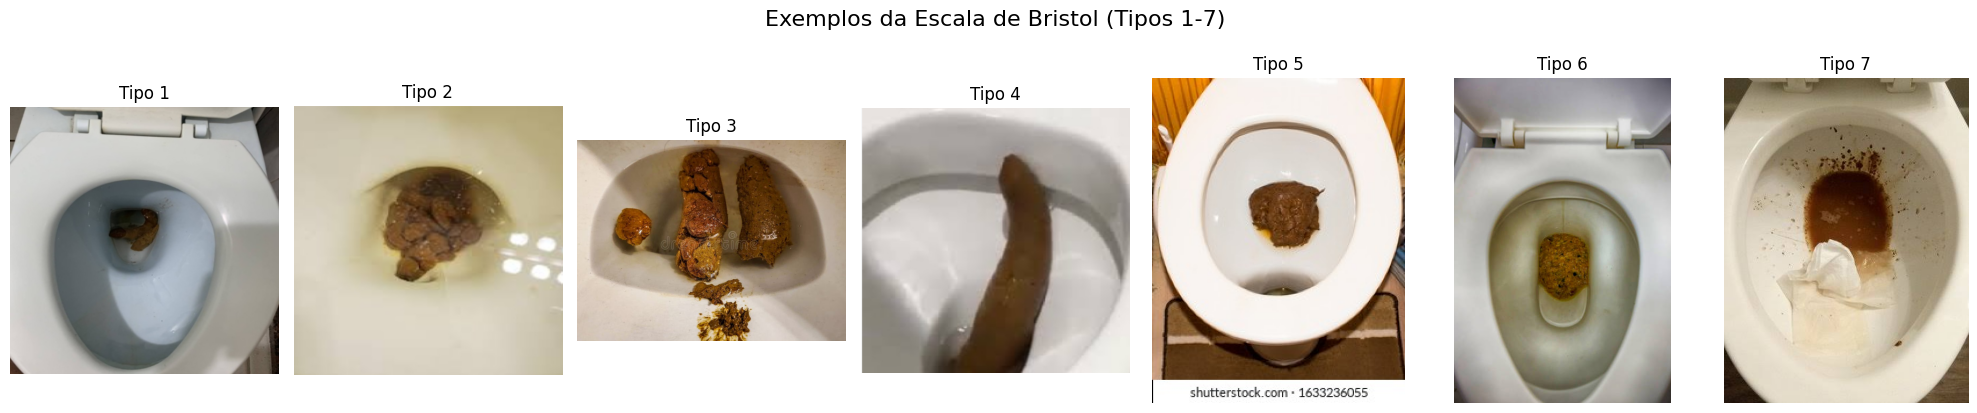

In [36]:
from PIL import Image

# Mostrar 1 exemplo de cada tipo Bristol
fig, axes = plt.subplots(1, 7, figsize=(20, 4))
fig.suptitle('Exemplos da Escala de Bristol (Tipos 1-7)', fontsize=16, y=1.02)

for bristol_type in range(1, 8):
    sample = df[df['bristol_type'] == bristol_type].iloc[0]
    img_path = dataset_path / sample['filename']
    img = Image.open(img_path)
    
    axes[bristol_type-1].imshow(img)
    axes[bristol_type-1].set_title(f'Tipo {bristol_type}')
    axes[bristol_type-1].axis('off')

plt.tight_layout()
plt.show()

## 3. Preparar os Dados

### Split: Train/Test (80/20)
- **Train (80%)**: Para treinar o modelo (com validation split interno)
- **Test (20%)**: Para avaliar o modelo final (não visto durante treino)

O modelo usará `validation_split` do Keras para separar automaticamente parte do train para validação.

In [37]:
# Adicionar caminho completo
df['filepath'] = df['filename'].apply(lambda x: str(dataset_path / x))

# Converter bristol_type para string (necessário para o ImageDataGenerator)
df['bristol_type_str'] = df['bristol_type'].astype(str)

# Split estratificado 80/20 (mantém proporção de classes)
train_df, test_df = train_test_split(
    df,
    test_size=0.2,  # 20% para teste
    stratify=df['bristol_type'],
    random_state=42
)

print(f"Train set: {len(train_df)} imagens ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_df)} imagens ({len(test_df)/len(df)*100:.1f}%)")

# Verificar distribuição
print("\nDistribuição no Train set:")
print(train_df['bristol_type'].value_counts().sort_index())
print("\nDistribuição no Test set:")
print(test_df['bristol_type'].value_counts().sort_index())

Train set: 168 imagens (79.6%)
Test set: 43 imagens (20.4%)

Distribuição no Train set:
bristol_type
1    25
2    10
3    21
4    34
5    28
6    29
7    21
Name: count, dtype: int64

Distribuição no Test set:
bristol_type
1    6
2    2
3    6
4    9
5    7
6    8
7    5
Name: count, dtype: int64


## 4. Data Augmentation

**Data Augmentation** cria variações das imagens originais para aumentar artificialmente o dataset:
- Rotação
- Zoom
- Flip horizontal
- Ajustes de brilho

Isso ajuda o modelo a generalizar melhor e evita overfitting.

In [38]:
# Configurações
IMG_SIZE = (224, 224)  # VGG16 usa 224x224
BATCH_SIZE = 16

# Data Augmentation para TREINO (cria variações das imagens)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normaliza pixels para [0, 1]
    validation_split=0.2,        # 20% do train será usado para validação
    rotation_range=20,           # Rotação aleatória até 20 graus
    width_shift_range=0.2,       # Deslocamento horizontal
    height_shift_range=0.2,      # Deslocamento vertical
    shear_range=0.2,             # Distorção
    zoom_range=0.2,              # Zoom aleatório
    horizontal_flip=True,        # Flip horizontal
    brightness_range=[0.8, 1.2], # Ajuste de brilho
    fill_mode='nearest'
)

# Para TESTE: apenas normalização (sem augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Criar gerador de TREINO (subset='training')
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='bristol_type_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    subset='training'  # Usa 80% do train_df
)

# Criar gerador de VALIDAÇÃO (subset='validation')
val_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='bristol_type_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'  # Usa 20% do train_df
)

# Criar gerador de TESTE
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='bristol_type_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nResumo dos conjuntos:")
print(f"Train: {train_generator.samples} imagens")
print(f"Validation: {val_generator.samples} imagens")
print(f"Test: {test_generator.samples} imagens")
print(f"\nClasses: {train_generator.class_indices}")

Found 135 validated image filenames belonging to 7 classes.
Found 33 validated image filenames belonging to 7 classes.
Found 43 validated image filenames belonging to 7 classes.

Resumo dos conjuntos:
Train: 135 imagens
Validation: 33 imagens
Test: 43 imagens

Classes: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


### Visualizar Data Augmentation

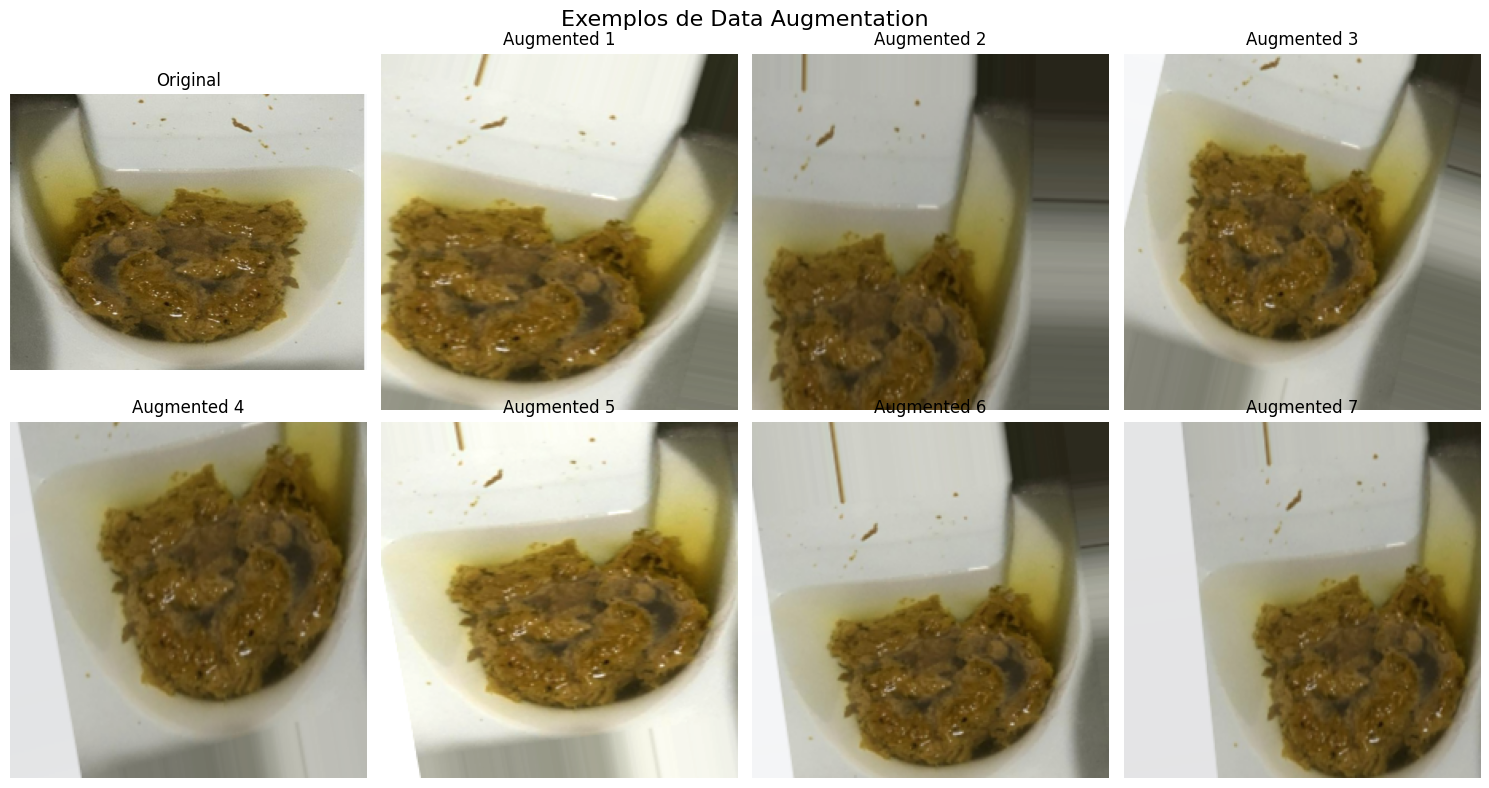

In [39]:
# Mostrar exemplos de augmentation
sample_img_path = train_df.iloc[0]['filepath']
sample_img = Image.open(sample_img_path)
sample_array = np.array(sample_img.resize(IMG_SIZE))
sample_array = sample_array.reshape((1,) + sample_array.shape)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Exemplos de Data Augmentation', fontsize=16)

axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Gerar variações
i = 1
for batch in train_datagen.flow(sample_array, batch_size=1):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(batch[0])
    axes[row, col].set_title(f'Augmented {i}')
    axes[row, col].axis('off')
    i += 1
    if i >= 8:
        break

plt.tight_layout()
plt.show()

## 5. Construir o Modelo - Abordagem 1: Feature Extraction

### Feature Extraction (Mais Simples)

Nesta abordagem:
1. **Congelamos** toda a base convolucional do VGG16
2. Usamos apenas como **extrator de features**
3. Treinamos **apenas o classificador** que adicionamos no topo

**Vantagens:**
- Treina muito rápido
- Funciona bem com poucos dados
- Menos risco de overfitting

**Quando usar:**
- Dataset pequeno (< 500 imagens)
- Primeiro experimento
- Hardware limitado

In [40]:
def create_feature_extraction_model():
    """
    Cria modelo com Feature Extraction:
    - Base VGG16 congelada (não treina)
    - Classificador novo (treina)
    """
    # Carregar VGG16 pré-treinada no ImageNet (sem o topo)
    base_model = VGG16(
        weights='imagenet',
        include_top=False,  # Remove o classificador original
        input_shape=(224, 224, 3)
    )
    
    # CONGELAR toda a base convolucional
    base_model.trainable = False
    
    # Construir novo classificador
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),           # Reduz dimensões
        Dense(512, activation='relu'),       # Camada densa
        BatchNormalization(),                # Normalização
        Dropout(0.5),                        # Regularização (evita overfitting)
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(7, activation='softmax')       # 7 classes (Bristol 1-7)
    ])
    
    return model

# Criar modelo
model_fe = create_feature_extraction_model()

# Compilar
model_fe.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_fe.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,543 (57.65 MB)

 Trainable params: 397,319 (1.52 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

### Callbacks para melhorar o treinamento

In [41]:
# Callbacks
callbacks = [
    # Para treino se não melhorar por 10 épocas
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduz learning rate se não melhorar
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Salva melhor modelo
    ModelCheckpoint(
        'best_model_fe.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

### Treinar o modelo

In [43]:
# Treinar
EPOCHS = 100

history_fe = model_fe.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7261 - loss: 0.7349
Epoch 1: val_accuracy did not improve from 0.48485
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7037 - loss: 0.7634 - val_accuracy: 0.3333 - val_loss: 1.5248 - learning_rate: 5.0000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6073 - loss: 1.0570
Epoch 2: val_accuracy improved from 0.48485 to 0.54545, saving model to best_model_fe.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6148 - loss: 0.9991 - val_accuracy: 0.5455 - val_loss: 1.5417 - learning_rate: 5.0000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6705 - loss: 0.8858
Epoch 3: val_accuracy did not improve from 0.54545
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6963 - loss: 0.8676 - val_accuracy: 0.5152 - val_loss: 1.5019 - learning_rate: 5.0000e-04
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6962 - loss: 0.8504
Epoch 4: val_accuracy did not improve from 0.54545
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6815 - loss: 0.9064 - val_accuracy: 0.3636 - val_loss: 1.4754 - learning_rate: 5.0000e-04
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6264 - loss: 1.0004
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 5: val_accuracy did not improve from 0.54545
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6444 - loss: 0.9195 - val_accuracy: 0.4242 - val_l

9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.6593 - loss: 0.9048 - val_accuracy: 0.6061 - val_loss: 1.6527 - learning_rate: 1.2500e-04
Epoch 18/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6830 - loss: 0.7965
Epoch 18: val_accuracy did not improve from 0.60606
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.6815 - loss: 0.7536 - val_accuracy: 0.3939 - val_loss: 1.4352 - learning_rate: 1.2500e-04
Epoch 19/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6387 - loss: 0.9988
Epoch 19: val_accuracy did not improve from 0.60606
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6667 - loss: 0.9348 - val_accuracy: 0.5152 - val_loss: 1.4787 - learning_rate: 1.2500e-04
Epoch 20/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7114 - loss: 0.7632
Epoch 20: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 20: val_accuracy did not improve from 0.60606
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.7259 - loss: 0.7448 - val_accuracy: 0.3939 -

### Visualizar curvas de aprendizado

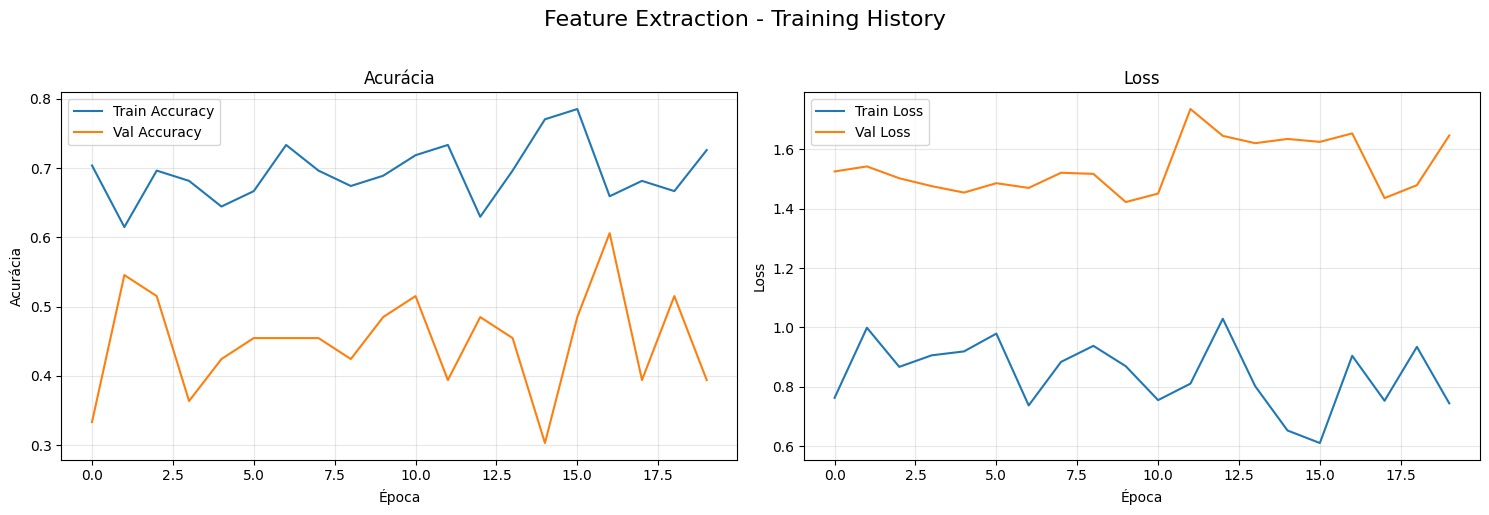

In [44]:
def plot_training_history(history, title='Model Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Acurácia')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Acurácia')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_history(history_fe, 'Feature Extraction - Training History')

## 6. Abordagem 2: Fine-Tuning

### Fine-Tuning (Mais Avançado)

Nesta abordagem:
1. **Congelamos** apenas as primeiras camadas (features básicas)
2. **Decongelamos** as últimas camadas da base convolucional
3. Treinamos as últimas camadas + classificador juntos

**Vantagens:**
- Potencialmente mais preciso
- Adapta features para seu domínio específico

**Desvantagens:**
- Treina mais devagar
- Mais risco de overfitting
- Precisa de learning rate menor

**Quando usar:**
- Se Feature Extraction não deu bons resultados
- Dataset médio (> 200 imagens)
- Seu problema é muito diferente do ImageNet

In [45]:
def create_finetuning_model():
    """
    Cria modelo com Fine-Tuning:
    - Primeiras camadas VGG16 congeladas
    - Últimas camadas VGG16 treináveis
    - Classificador novo
    """
    # Carregar VGG16 pré-treinada
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    # CONGELAR apenas as primeiras camadas (features básicas)
    # VGG16 tem 19 camadas, vamos congelar as primeiras 15
    for layer in base_model.layers[:15]:
        layer.trainable = False
    
    # Últimas 4 camadas serão treinadas
    for layer in base_model.layers[15:]:
        layer.trainable = True
    
    # Construir modelo
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(7, activation='softmax')
    ])
    
    return model

# Criar modelo
model_ft = create_finetuning_model()

# Compilar com learning rate MENOR (importante para fine-tuning!)
model_ft.compile(
    optimizer=Adam(learning_rate=0.0001),  # 10x menor que feature extraction
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar quantas camadas são treináveis
trainable_count = sum([1 for layer in model_ft.layers if layer.trainable])
print(f"\nCamadas treináveis: {trainable_count}")
print(f"Camadas congeladas: {len(model_ft.layers) - trainable_count}")


Camadas treináveis: 9
Camadas congeladas: 0


In [46]:
# Callbacks para fine-tuning
callbacks_ft = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,  # Mais paciência para fine-tuning
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_ft.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Treinar
history_ft = model_ft.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_ft,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1078 - loss: 3.0715
Epoch 1: val_accuracy improved from None to 0.06061, saving model to best_model_ft.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.1111 - loss: 3.0746 - val_accuracy: 0.0606 - val_loss: 1.9612 - learning_rate: 1.0000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2762 - loss: 2.2640
Epoch 2: val_accuracy improved from 0.06061 to 0.12121, saving model to best_model_ft.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.2667 - loss: 2.1679 - val_accuracy: 0.1212 - val_loss: 1.9397 - learning_rate: 1.0000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2238 - loss: 2.2773
Epoch 3: val_accuracy improved from 0.12121 to 0.15152, saving model to best_model_ft.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.2370 - loss: 2.2204 - val_accuracy: 0.1515 - val_loss: 1.9219 - learning_rate: 1.0000e-04
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2011 - loss: 2.1221
Epoch 4: val_accuracy improved from 0.15152 to 0.18182, saving model to best_model_ft.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.2222 - loss: 2.2071 - val_accuracy: 0.1818 - val_loss: 1.8998 - learning_rate: 1.0000e-04
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3254 - loss: 1.8899
Epoch 5: val_accuracy improved from 0.18182 to 0.21212, saving model to best_model_ft.h5


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5037 - loss: 1.3142 - val_accuracy: 0.4545 - val_loss: 1.6638 - learning_rate: 1.0000e-04
Epoch 18/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4828 - loss: 1.3412
Epoch 18: val_accuracy did not improve from 0.45455
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.5259 - loss: 1.3276 - val_accuracy: 0.4242 - val_loss: 1.6851 - learning_rate: 1.0000e-04
Epoch 19/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6072 - loss: 1.1051
Epoch 19: val_accuracy did not improve from 0.45455
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5926 - loss: 1.0846 - val_accuracy: 0.3636 - val_loss: 1.6987 - learning_rate: 1.0000e-04
Epoch 20/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6038 - loss: 1.0977
Epoch 20: val_accuracy did not improve from 0.45455
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.5852 - loss: 1.1491 - val_accuracy: 0.3636 - val_loss: 1.7389 - learning_rate: 1.0000e-04
Epoch 21/100
9/9 ━━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.7111 - loss: 0.7924 - val_accuracy: 0.4848 - val_loss: 1.5443 - learning_rate: 1.0000e-04
Epoch 30/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7087 - loss: 0.6828
Epoch 30: val_accuracy did not improve from 0.48485
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6667 - loss: 0.8644 - val_accuracy: 0.3939 - val_loss: 1.8443 - learning_rate: 1.0000e-04
Epoch 31/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7612 - loss: 0.7268
Epoch 31: val_accuracy did not improve from 0.48485
9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.7778 - loss: 0.7042 - val_accuracy: 0.3636 - val_loss: 2.0986 - learning_rate: 1.0000e-04
Epoch 32/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6833 - loss: 0.9004
Epoch 32: val_accuracy did not improve from 0.48485
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.7111 - loss: 0.8347 - val_accuracy: 0.3636 - val_loss: 1.7992 - learning_rate: 1.0000e-04
Epoch 33/100
9/9 ━━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8667 - loss: 0.3987 - val_accuracy: 0.5152 - val_loss: 1.6028 - learning_rate: 5.0000e-05
Epoch 47/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8723 - loss: 0.3272
Epoch 47: val_accuracy did not improve from 0.51515
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8889 - loss: 0.3088 - val_accuracy: 0.5152 - val_loss: 1.3974 - learning_rate: 5.0000e-05
Epoch 48/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8812 - loss: 0.3109
Epoch 48: val_accuracy did not improve from 0.51515
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.8741 - loss: 0.3401 - val_accuracy: 0.5152 - val_loss: 1.5760 - learning_rate: 5.0000e-05
Epoch 49/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9206 - loss: 0.3141
Epoch 49: val_accuracy did not improve from 0.51515
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9333 - loss: 0.3259 - val_accuracy: 0.5152 - val_loss: 1.5995 - learning_rate: 5.0000e-05
Epoch 50/100
9/9 ━━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9111 - loss: 0.2769 - val_accuracy: 0.5455 - val_loss: 1.6891 - learning_rate: 5.0000e-05
Epoch 52/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9342 - loss: 0.2347
Epoch 52: val_accuracy did not improve from 0.54545
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.9259 - loss: 0.2356 - val_accuracy: 0.5152 - val_loss: 1.6414 - learning_rate: 5.0000e-05
Epoch 53/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9243 - loss: 0.2593
Epoch 53: val_accuracy did not improve from 0.54545
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8963 - loss: 0.2998 - val_accuracy: 0.5455 - val_loss: 1.7010 - learning_rate: 5.0000e-05
Epoch 54/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9131 - loss: 0.2712
Epoch 54: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 54: val_accuracy did not improve from 0.54545
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.8963 - loss: 0.3009 - val_accuracy: 0.5455 

9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9259 - loss: 0.2565 - val_accuracy: 0.6061 - val_loss: 1.6618 - learning_rate: 2.5000e-05
Epoch 57/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9070 - loss: 0.2289
Epoch 57: val_accuracy did not improve from 0.60606
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8889 - loss: 0.2804 - val_accuracy: 0.5152 - val_loss: 1.6612 - learning_rate: 2.5000e-05
Epoch 58/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8918 - loss: 0.3090
Epoch 58: val_accuracy did not improve from 0.60606
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8593 - loss: 0.3466 - val_accuracy: 0.4848 - val_loss: 1.9624 - learning_rate: 2.5000e-05
Epoch 59/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9235 - loss: 0.2660
Epoch 59: val_accuracy did not improve from 0.60606
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9333 - loss: 0.2596 - val_accuracy: 0.4848 - val_loss: 1.6890 - learning_rate: 2.5000e-05
Epoch 60/100
9/9 ━━━━━━━━━━━━━━

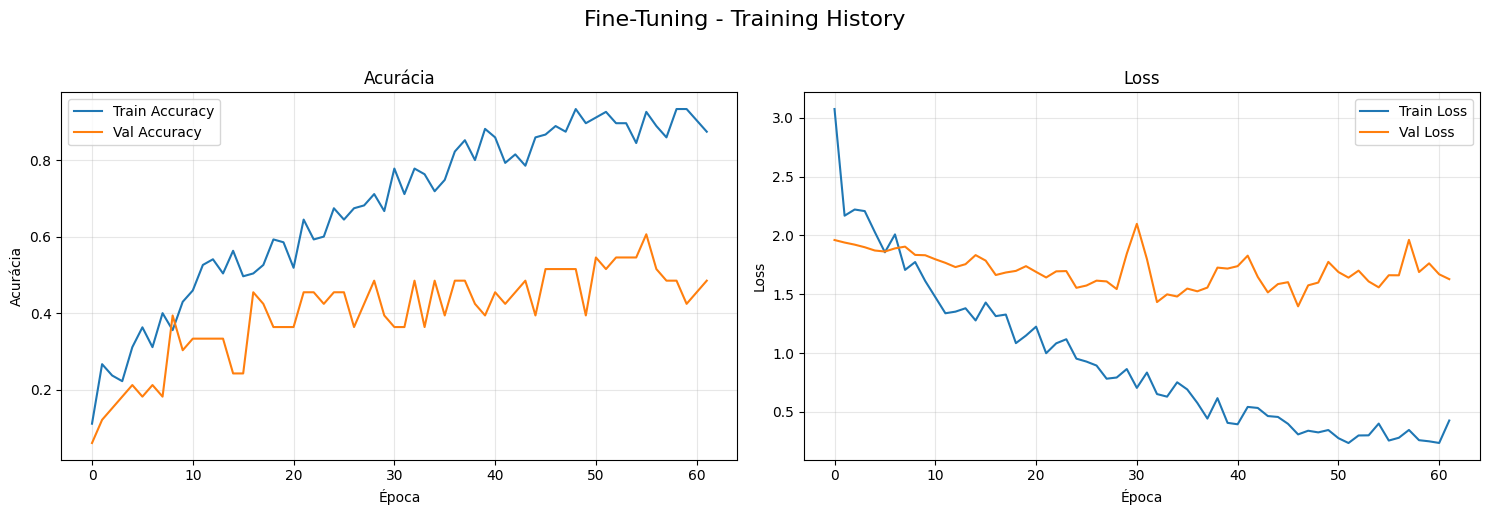

In [47]:
plot_training_history(history_ft, 'Fine-Tuning - Training History')

## 7. Avaliar os Modelos no Test Set


Avaliação: Feature Extraction

Test Loss: 1.9706
Test Accuracy: 0.2558

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.50      0.50         6
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         6
           4       0.40      0.22      0.29         9
           5       0.17      0.14      0.15         7
           6       0.29      0.62      0.40         8
           7       0.00      0.00      0.00         5

    accuracy                           0.26        43
   macro avg       0.19      0.21      0.19        43
weighted avg       0.24      0.26      0.23        43



/Users/elorr/Documents/feces_analysis/feces_analysis/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/elorr/Documents/feces_analysis/feces_analysis/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/elorr/Documents/feces_analysis/feces_analysis/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

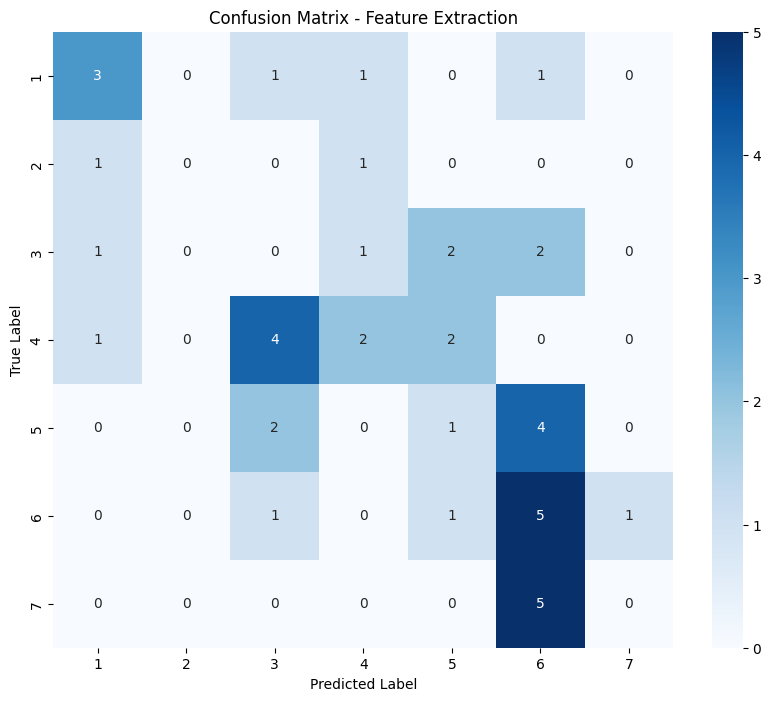


Avaliação: Fine-Tuning

Test Loss: 2.2810
Test Accuracy: 0.2558

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.50      0.60         6
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         6
           4       0.38      0.33      0.35         9
           5       0.27      0.43      0.33         7
           6       0.12      0.12      0.12         8
           7       0.20      0.20      0.20         5

    accuracy                           0.26        43
   macro avg       0.25      0.23      0.23        43
weighted avg       0.27      0.26      0.26        43



/Users/elorr/Documents/feces_analysis/feces_analysis/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/elorr/Documents/feces_analysis/feces_analysis/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/elorr/Documents/feces_analysis/feces_analysis/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

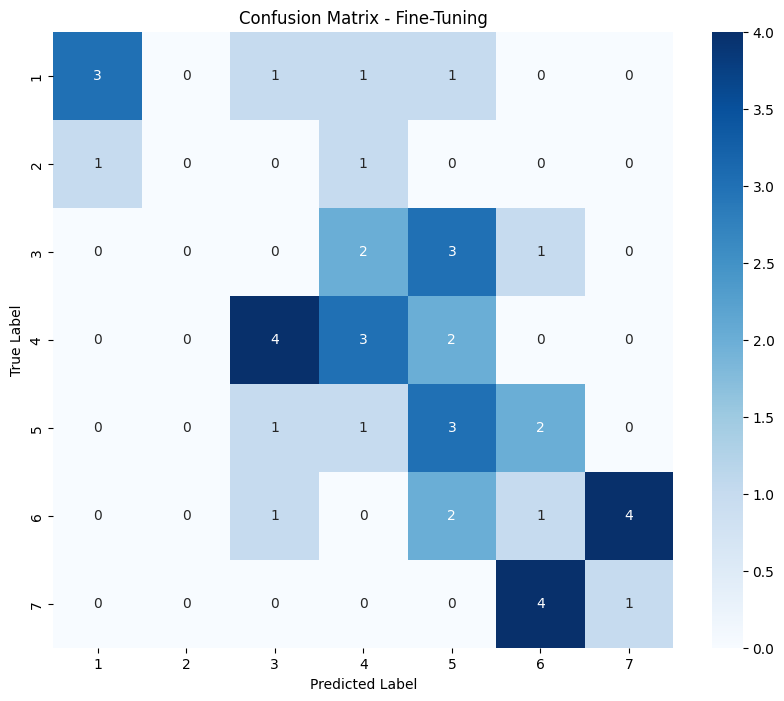

In [48]:
def evaluate_model(model, test_generator, model_name):
    """
    Avalia modelo e mostra métricas detalhadas
    """
    print(f"\n{'='*50}")
    print(f"Avaliação: {model_name}")
    print(f"{'='*50}\n")
    
    # Avaliar
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Predições
    test_generator.reset()
    y_pred_proba = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_generator.classes
    
    # Classes
    class_names = [str(i+1) for i in range(7)]
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return test_acc

# Avaliar ambos os modelos
acc_fe = evaluate_model(model_fe, test_generator, "Feature Extraction")
acc_ft = evaluate_model(model_ft, test_generator, "Fine-Tuning")

## 8. Comparação dos Modelos


Comparação dos Modelos:
               Modelo  Test Accuracy
0  Feature Extraction       0.255814
1         Fine-Tuning       0.255814


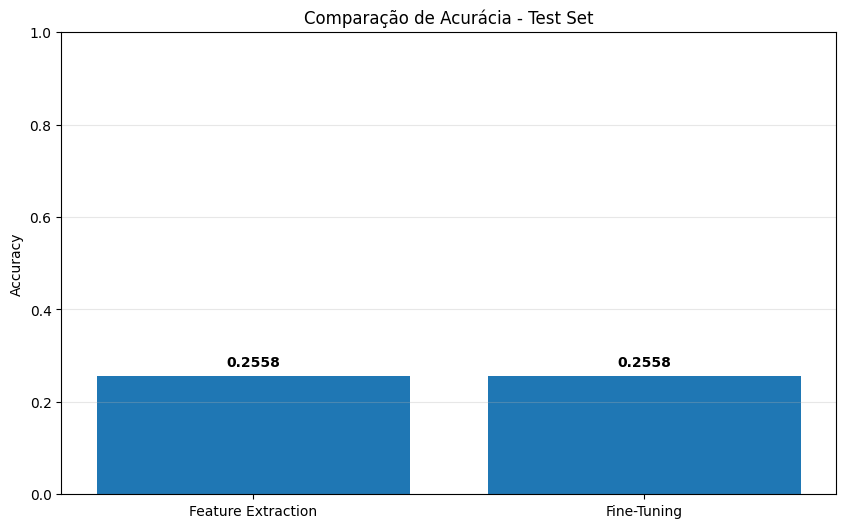


🏆 Melhor modelo: Feature Extraction


In [49]:
# Comparar resultados
comparison = pd.DataFrame({
    'Modelo': ['Feature Extraction', 'Fine-Tuning'],
    'Test Accuracy': [acc_fe, acc_ft]
})

print("\nComparação dos Modelos:")
print(comparison)

# Visualizar
plt.figure(figsize=(10, 6))
plt.bar(comparison['Modelo'], comparison['Test Accuracy'])
plt.title('Comparação de Acurácia - Test Set')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
for i, v in enumerate(comparison['Test Accuracy']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Escolher melhor modelo
best_model_name = comparison.loc[comparison['Test Accuracy'].idxmax(), 'Modelo']
print(f"\n🏆 Melhor modelo: {best_model_name}")

## 9. Fazer Predições em Novas Imagens

In [51]:
def predict_image(model, img_path, true_label=None):
    """
    Prediz a classe de uma imagem e mostra o resultado
    """
    # Carregar e preprocessar imagem
    img = Image.open(img_path).resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predizer
    pred_proba = model.predict(img_array, verbose=0)[0]
    pred_class = np.argmax(pred_proba) + 1  # +1 porque classes vão de 1-7
    confidence = pred_proba[pred_class - 1]
    
    # Visualizar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Imagem
    ax1.imshow(img)
    title = f'Predição: Tipo {pred_class} ({confidence:.2%})'
    if true_label:
        title += f'\nReal: Tipo {true_label}'
    ax1.set_title(title)
    ax1.axis('off')
    
    # Probabilidades
    classes = [str(i) for i in range(1, 8)]
    ax2.bar(classes, pred_proba)
    ax2.set_title('Probabilidades por Classe')
    ax2.set_xlabel('Tipo Bristol')
    ax2.set_ylabel('Probabilidade')
    ax2.set_ylim([0, 1])
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return pred_class, confidence

# Testar com algumas imagens do test set
print("Predições de exemplo (usando melhor modelo):")
best_model = model_ft if acc_ft > acc_fe else model_fe

for i in range(min(3, len(test_df))):
    sample = test_df.iloc[i]
    pred_class, conf = predict_image(
        best_model, 
        sample['filepath'], 
        true_label=sample['bristol_type']
    )

Predições de exemplo (usando melhor modelo):


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "vgg16" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 224, 224, 4)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 224, 224, 4), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

## 10. Salvar Modelo Final

In [ ]:
# Salvar o melhor modelo
best_model.save('bristol_classifier_final.h5')
print("✓ Modelo salvo como 'bristol_classifier_final.h5'")

# Também salvar em formato SavedModel (mais moderno)
best_model.save('bristol_classifier_final', save_format='tf')
print("✓ Modelo salvo como 'bristol_classifier_final/' (formato TensorFlow)")

## Conclusão e Próximos Passos

### Você criou com sucesso um classificador de fezes pela escala de Bristol!

**O que fizemos:**
1. ✓ Carregamos e exploramos o dataset (211 imagens, 7 classes)
2. ✓ Aplicamos Data Augmentation para aumentar a variabilidade
3. ✓ Testamos duas abordagens de Transfer Learning:
   - Feature Extraction (mais rápido, simples)
   - Fine-Tuning (mais preciso, complexo)
4. ✓ Avaliamos e comparamos os modelos
5. ✓ Salvamos o melhor modelo

### Próximos passos para melhorar:

1. **Coletar mais dados**: 200 imagens é relativamente pouco. Idealmente 500-1000+ por classe
2. **Tentar outras arquiteturas**: ResNet50, EfficientNet, MobileNet
3. **Ensemble**: Combinar predições de múltiplos modelos
4. **Class weights**: Se algumas classes têm menos exemplos, usar pesos
5. **Cross-validation**: K-fold para avaliação mais robusta
6. **Deploy**: Criar API ou aplicativo para uso em produção

### Para usar o modelo salvo depois:

```python
from tensorflow.keras.models import load_model
model = load_model('bristol_classifier_final.h5')
```